正在读取文件： /openbayes/home/MAPDN/test_record_var_voltage_control-case33_3min_final-distributed-maddpg-bowl-0_day730.pickle
包含字段： ['pv_active', 'pv_reactive', 'bus_active', 'bus_reactive', 'bus_voltage', 'line_loss']

pv_active
  shape = (480, 6)
  min   = 0.000000
  max   = 0.321249
  mean  = 0.021336
  std   = 0.046589

pv_reactive
  shape = (480, 6)
  min   = -2.845512
  max   = 1.126741
  mean  = 0.098297
  std   = 0.116099

bus_active
  shape = (480, 33)
  min   = -2.080996
  max   = 0.373435
  mean  = -0.000650
  std   = 0.238409

bus_reactive
  shape = (480, 33)
  min   = -4.401957
  max   = 2.999591
  mean  = -0.000454
  std   = 0.082443

bus_voltage
  shape = (480, 33)
  min   = 0.851048
  max   = 1.015768
  mean  = 0.990776
  std   = 0.006856

line_loss
  shape = (480, 32)
  min   = 0.000000
  max   = 0.100635
  mean  = 0.000670
  std   = 0.001537


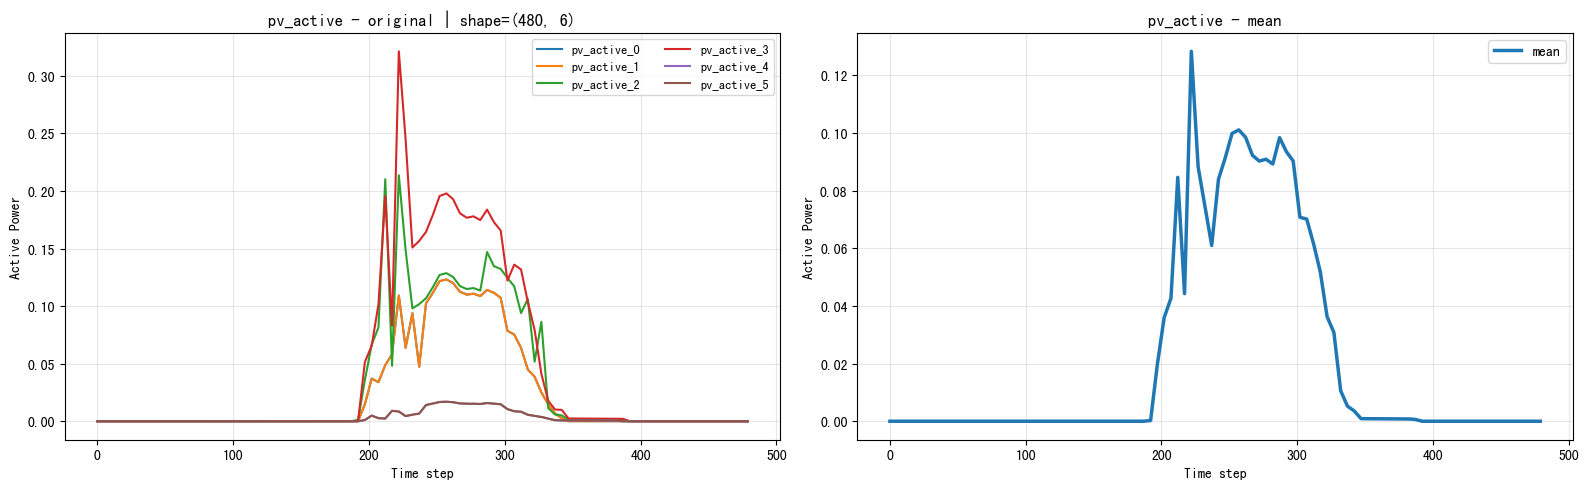

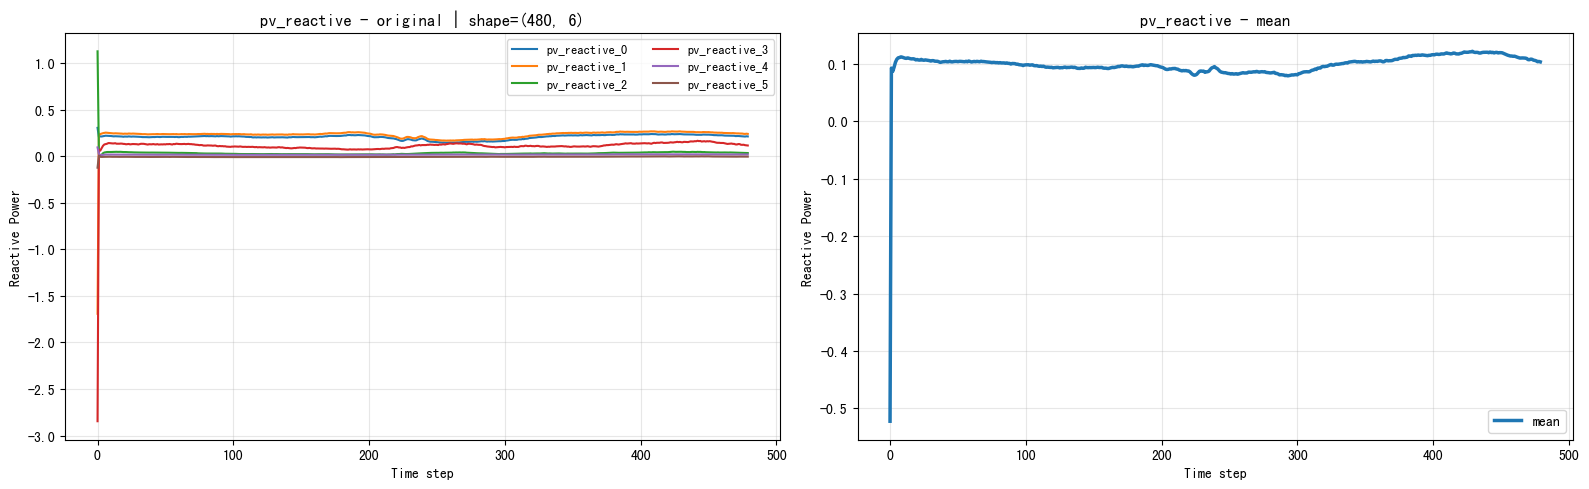

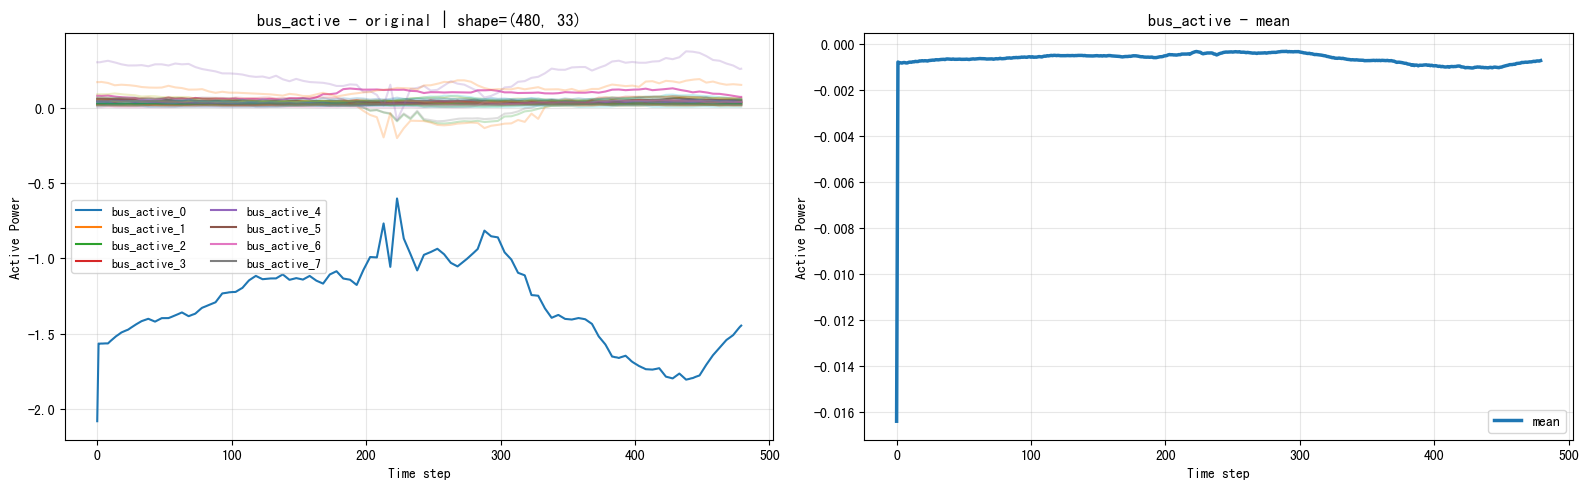

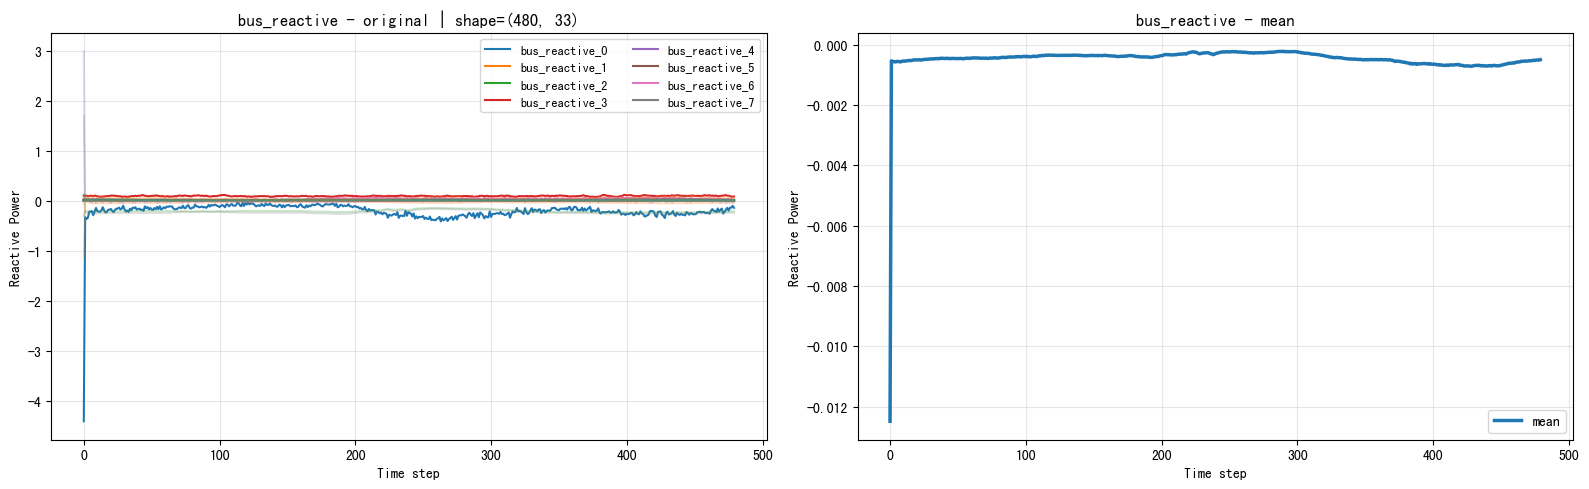

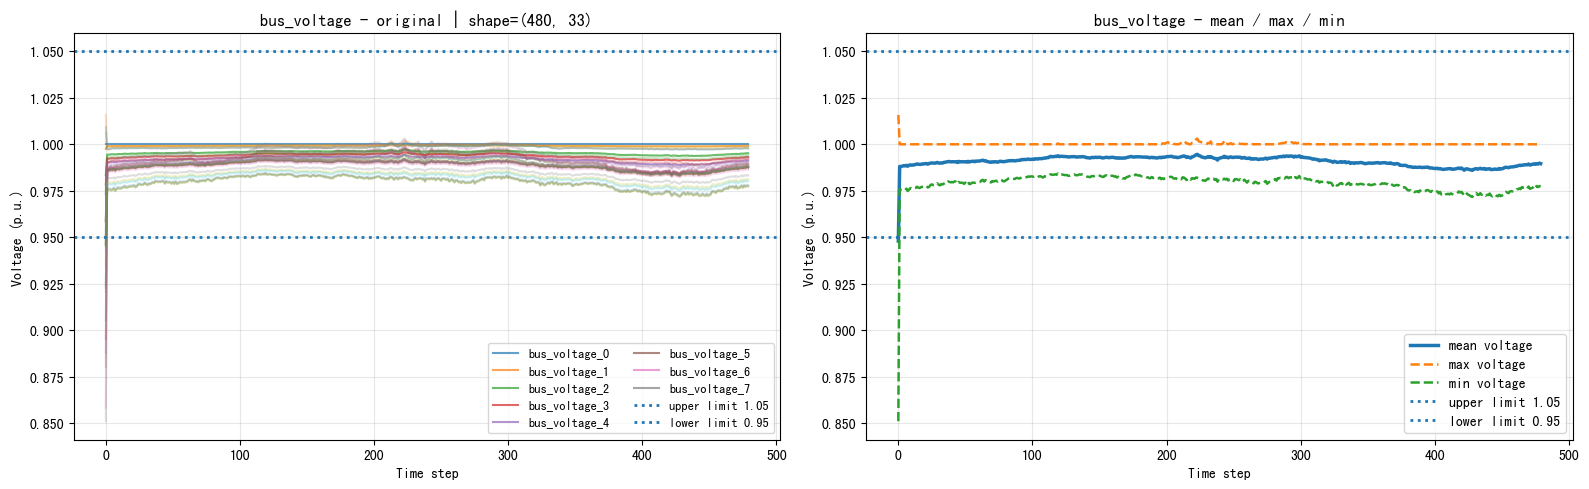

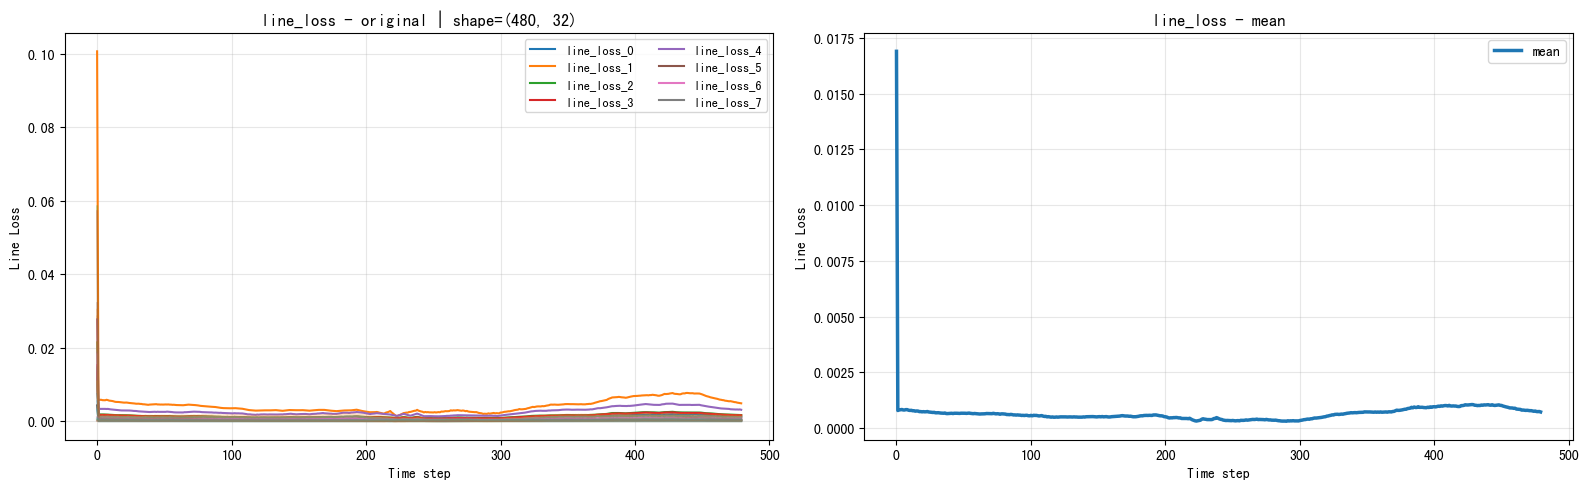

In [2]:
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ===== 1) 自动寻找结果文件 =====
files = sorted(glob.glob("/openbayes/home/MAPDN/test_record_*.pickle"))
if not files:
    raise FileNotFoundError("没有找到 /openbayes/home/MAPDN/test_record_var_voltage_control-case33_3min_final-distributed-maac_masked-l1-_day730.pickle")

fname = files[-1]   # 默认取最新一个
print("正在读取文件：", fname)

# ===== 2) 读取 pickle =====
with open(fname, "rb") as f:
    rec = pickle.load(f)

print("包含字段：", list(rec.keys()))

# ===== 3) 工具函数 =====
def to_2d(x):
    arr = np.array(x)
    arr = np.squeeze(arr)
    if arr.ndim == 1:
        arr = arr[:, None]
    return arr

def plot_multiseries_with_mean(data, title, ylabel, legend_prefix=None, max_legend_lines=8):
    arr = to_2d(data)
    T, N = arr.shape

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # ===== 左图：原图（多条线）=====
    ax = axes[0]
    for i in range(N):
        if i < max_legend_lines:
            label = f"{legend_prefix}_{i}" if legend_prefix else f"{title}_{i}"
            ax.plot(arr[:, i], label=label)
        else:
            ax.plot(arr[:, i], alpha=0.25)

    ax.set_xlabel("Time step")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{title} - original | shape={arr.shape}")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=9)

    # ===== 右图：平均值=====
    ax = axes[1]
    mean_curve = arr.mean(axis=1)
    ax.plot(mean_curve, linewidth=2.5, label="mean")

    ax.set_xlabel("Time step")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{title} - mean")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

def plot_bus_voltage_with_mean(data, max_legend_lines=8):
    arr = to_2d(data)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # ===== 左图：原图（所有 bus）=====
    ax = axes[0]
    for i in range(arr.shape[1]):
        if i < max_legend_lines:
            ax.plot(arr[:, i], alpha=0.7, label=f"bus_voltage_{i}")
        else:
            ax.plot(arr[:, i], alpha=0.25)

    ax.axhline(1.05, linestyle=":", linewidth=2, label="upper limit 1.05")
    ax.axhline(0.95, linestyle=":", linewidth=2, label="lower limit 0.95")
    ax.set_xlabel("Time step")
    ax.set_ylabel("Voltage (p.u.)")
    ax.set_title(f"bus_voltage - original | shape={arr.shape}")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=9)

    # ===== 右图：平均值=====
    ax = axes[1]
    ax.plot(arr.mean(axis=1), linewidth=2.5, label="mean voltage")
    ax.plot(arr.max(axis=1), linestyle="--", linewidth=1.8, label="max voltage")
    ax.plot(arr.min(axis=1), linestyle="--", linewidth=1.8, label="min voltage")
    ax.axhline(1.05, linestyle=":", linewidth=2, label="upper limit 1.05")
    ax.axhline(0.95, linestyle=":", linewidth=2, label="lower limit 0.95")

    ax.set_xlabel("Time step")
    ax.set_ylabel("Voltage (p.u.)")
    ax.set_title("bus_voltage - mean / max / min")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

def print_basic_stats(name, data):
    arr = np.array(data)
    arr = np.squeeze(arr)
    print(f"\n{name}")
    print(f"  shape = {arr.shape}")
    print(f"  min   = {np.min(arr):.6f}")
    print(f"  max   = {np.max(arr):.6f}")
    print(f"  mean  = {np.mean(arr):.6f}")
    print(f"  std   = {np.std(arr):.6f}")

# ===== 4) 打印基本统计 =====
for key in ["pv_active", "pv_reactive", "bus_active", "bus_reactive", "bus_voltage", "line_loss"]:
    if key in rec:
        print_basic_stats(key, rec[key])
    else:
        print(f"\n{key}\n  [缺失] 文件中没有这个字段")

# ===== 5) 一次性画图 =====
if "pv_active" in rec:
    plot_multiseries_with_mean(
        rec["pv_active"],
        title="pv_active",
        ylabel="Active Power",
        legend_prefix="pv_active",
        max_legend_lines=8
    )

if "pv_reactive" in rec:
    plot_multiseries_with_mean(
        rec["pv_reactive"],
        title="pv_reactive",
        ylabel="Reactive Power",
        legend_prefix="pv_reactive",
        max_legend_lines=8
    )

if "bus_active" in rec:
    plot_multiseries_with_mean(
        rec["bus_active"],
        title="bus_active",
        ylabel="Active Power",
        legend_prefix="bus_active",
        max_legend_lines=8
    )

if "bus_reactive" in rec:
    plot_multiseries_with_mean(
        rec["bus_reactive"],
        title="bus_reactive",
        ylabel="Reactive Power",
        legend_prefix="bus_reactive",
        max_legend_lines=8
    )

if "bus_voltage" in rec:
    plot_bus_voltage_with_mean(
        rec["bus_voltage"],
        max_legend_lines=8
    )

if "line_loss" in rec:
    plot_multiseries_with_mean(
        rec["line_loss"],
        title="line_loss",
        ylabel="Line Loss",
        legend_prefix="line_loss",
        max_legend_lines=8
    )